In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=250

In [2]:
data = pd.read_csv("Maha_Agri.csv")

In [3]:
data.head(10)

,District,Crop,Year,Season,Area,Production,Yield
0,NANDED,Castor seed,2015-16,Kharif,10.0,1.0,0.10
1,SINDHUDURG,Castor seed,2015-16,Kharif,5.0,1.0,0.20
2,LATUR,Groundnut,2015-16,Summer,8.0,1.0,0.13
3,NANDED,Linseed,2015-16,Rabi,10.0,1.0,0.10
4,GADCHIROLI,Moong(Green Gram),2015-16,Summer,3.0,1.0,0.33
5,JALNA,Niger seed,2015-16,Kharif,20.0,1.0,0.05
6,RATNAGIRI,Sesamum,2015-16,Rabi,2.0,1.0,0.50
7,SINDHUDURG,Sesamum,2015-16,Rabi,2.0,1.0,0.50
8,DHULE,Sunflower,2015-16,Rabi,5.0,1.0,0.20
9,SINDHUDURG,Sunflower,2015-16,Rabi,5.0,1.0,0.20


# we are only keeping the records of - Kharif and Rabi Season.
# We have Removed the records of - Whole Year and Summer.

In [4]:
# 1. Keep only Kharif and Rabi seasons
filtered_data = data[data["Season"].isin(["Kharif", "Rabi"])]

filtered_data.head(10)

,District,Crop,Year,Season,Area,Production,Yield
0,NANDED,Castor seed,2015-16,Kharif,10.0,1.0,0.10
1,SINDHUDURG,Castor seed,2015-16,Kharif,5.0,1.0,0.20
3,NANDED,Linseed,2015-16,Rabi,10.0,1.0,0.10
5,JALNA,Niger seed,2015-16,Kharif,20.0,1.0,0.05
6,RATNAGIRI,Sesamum,2015-16,Rabi,2.0,1.0,0.50
7,SINDHUDURG,Sesamum,2015-16,Rabi,2.0,1.0,0.50
8,DHULE,Sunflower,2015-16,Rabi,5.0,1.0,0.20
9,SINDHUDURG,Sunflower,2015-16,Rabi,5.0,1.0,0.20
10,PUNE,Castor seed,2018-19,Kharif,3.0,1.0,0.33
12,GADCHIROLI,Moong(Green Gram),2018-19,Kharif,10.0,1.0,0.10


In [5]:
print("\nData Types:")
print(filtered_data.dtypes)
print("\n================================")
print("\nDataset Shape:\n")
print(filtered_data.shape)
print("\n================================")
print("\nMissing Values:\n")
print(filtered_data.isnull().sum())


Data Types:
District       object
Crop           object
Year           object
Season         object
Area          float64
Production    float64
Yield         float64
dtype: object


Dataset Shape:

(1845, 7)


Missing Values:

District      0
Crop          0
Year          0
Season        0
Area          0
Production    0
Yield         0
dtype: int64


In [6]:
filtered_data.describe()

,Area,Production,Yield
count,1845.000000,1.845000e+03,1845.000000
mean,30954.941789,4.125727e+04,0.798081
std,73698.013486,1.042428e+05,0.748561
min,0.500000,1.000000e+00,0.010000
25%,100.000000,3.000000e+01,0.250000
50%,300.000000,1.000000e+02,0.500000
75%,29100.000000,3.440000e+04,1.030000
max,765000.000000,1.097100e+06,7.890000


In [7]:
# Data Cleaning

In [8]:
data_kharif = filtered_data[(filtered_data['Season'] == 'Kharif') & (filtered_data['Area'] > 100) & (filtered_data['Production'] > 100)].sort_values(by='Year')
data_rabi = filtered_data[(filtered_data['Season'] == 'Rabi') & (filtered_data['Area'] > 100) & (filtered_data['Production'] > 100)].sort_values(by='Year')

In [9]:
# Handle outliers (for numerical columns)
def handle_outliers(df, columns):
    for col in columns:
        if col in df.select_dtypes(include=np.number).columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

    return lower_bound,upper_bound

In [10]:
kharif_out = handle_outliers(data_kharif,['Yield'])
rabi_out  = handle_outliers(data_rabi,['Yield'])

print("Kharif Upper and Lower Limit")
print(f"Lower Bound : {kharif_out[0]}")
print(f"Upper Bound : {kharif_out[1]}")
print("====================================================")
print("Rabi Upper and Lower Limit")
print(f"Lower Bound : {rabi_out[0]}")
print(f"Upper Bound : {rabi_out[1]}")


Kharif Upper and Lower Limit
Lower Bound : -0.98375
Upper Bound : 3.42625
Rabi Upper and Lower Limit
Lower Bound : -0.7237500000000001
Upper Bound : 3.2262500000000003


In [11]:
kharif_outliers = data_kharif[(data_kharif['Yield'] < kharif_out[0]) | (data_kharif['Yield'] > kharif_out[1])]
rabi_outliers = data_rabi[(data_rabi['Yield'] < rabi_out[0]) | (data_rabi['Yield'] > rabi_out[1])]
print(f"Total Records of Kharif Dataset : {data_kharif.shape}")
print(f"Total Records of Rabi Dataset : {data_rabi.shape}")
print("="*40)
print(f"Total outliers in Kharif dataset: {len(kharif_outliers)}")
print(f"Total outliers in Rabi dataset: {len(rabi_outliers)}")

Total Records of Kharif Dataset : (452, 7)
Total Records of Rabi Dataset : (268, 7)
Total outliers in Kharif dataset: 3
Total outliers in Rabi dataset: 4


# We are going to keep outliers and build model first.
# then we are going to build model removing outliers.
# then we are going to cap outliers and build the model.
# At last we are going to compare all three models and interpret it.

In [12]:
# Data Visualization

In [13]:
# ==============================
# District-Wise Crop Production
# ==============================
# Unique districts
districts = filtered_data['District'].unique()
n_districts = len(districts)

import math
# Define subplot grid
cols = 3
rows = math.ceil(n_districts / cols)


fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()


# Loop through each district and plot crops vs production
for i, district in enumerate(districts):
  district_data = filtered_data[filtered_data['District'] == district]
  sns.barplot(x='Crop', y='Production', data=district_data, ci=None, ax=axes[i])
  axes[i].set_title(f"{district}", fontsize=14)
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
  axes[i].set_ylabel("Total Production")
  axes[i].set_xlabel("Crop")


# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.savefig("District-Wise Crop Distribution(kharif and rabi only).jpg")
plt.show()

# we have plotted all the crops based on all the districts of maharashtra.
# here the values of production are fluctuating for some crops like, in sindhudurg district the values are - 100000 to 600000 and others have values between 0.0 to 4.

In [14]:
#  Drop 'Production' since not required
filtered_data = filtered_data.drop(columns=["Production"])
filtered_data.head(10)

,District,Crop,Year,Season,Area,Yield
0,NANDED,Castor seed,2015-16,Kharif,10.0,0.10
1,SINDHUDURG,Castor seed,2015-16,Kharif,5.0,0.20
3,NANDED,Linseed,2015-16,Rabi,10.0,0.10
5,JALNA,Niger seed,2015-16,Kharif,20.0,0.05
6,RATNAGIRI,Sesamum,2015-16,Rabi,2.0,0.50
7,SINDHUDURG,Sesamum,2015-16,Rabi,2.0,0.50
8,DHULE,Sunflower,2015-16,Rabi,5.0,0.20
9,SINDHUDURG,Sunflower,2015-16,Rabi,5.0,0.20
10,PUNE,Castor seed,2018-19,Kharif,3.0,0.33
12,GADCHIROLI,Moong(Green Gram),2018-19,Kharif,10.0,0.10


In [15]:
# Feature selection and preprocessing
target = 'Yield'
features = filtered_data.drop(columns=[target])

In [16]:
# Separate categorical and numerical columns
categorical_columns = features.select_dtypes(include=['object']).columns
numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns

In [17]:
# Encode categorical data
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_encoded = encoder.fit_transform(features[categorical_columns]).toarray()
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

In [18]:
# Scale numerical data
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(features[numerical_columns])

In [19]:
# Combine processed features
X_processed = np.hstack((numerical_scaled, categorical_encoded))
feature_names = list(numerical_columns) + list(categorical_feature_names)

In [20]:
X = X_processed
y = filtered_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Function for all evaluation metrics
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [22]:
# Making a list of all the models we are going to use
models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42)
}
model_list = []
r2_list =[]

In [23]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.4425
- Mean Absolute Error: 0.2992
- R2 Score: 0.6592
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4061
- Mean Absolute Error: 0.2972
- R2 Score: 0.6705


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.3564
- Mean Absolute Error: 0.2149
- R2 Score: 0.7789
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3435
- Mean Absolute Error: 0.2362
- R2 Score: 0.7643


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4418
- Mean Absolute Error: 0.2776
- R2 Score: 0.6100


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1483
- Mean Absolute Error: 0.0849
- R2 Score: 0.96

In [24]:
# Find the best model based on R2 score
best_model_index = r2_list.index(max(r2_list))
best_model_name = model_list[best_model_index]
best_model = list(models.values())[best_model_index]

print(f"Best Model: {best_model_name}")

# Use the best model to make predictions on the test set
y_pred_best_model = best_model.predict(X_test)

# Evaluate the best model
mae_best, rmse_best, r2_best = evaluate_model(y_test, y_pred_best_model)

print('\nModel performance for Test set (Best Model)')
print("- Root Mean Squared Error: {:.4f}".format(rmse_best))
print("- Mean Absolute Error: {:.4f}".format(mae_best))
print("- R2 Score: {:.4f}".format(r2_best))

Best Model: Random Forest Regressor

Model performance for Test set (Best Model)
- Root Mean Squared Error: 0.3264
- Mean Absolute Error: 0.2073
- R2 Score: 0.7871


In [25]:
score = r2_best*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 78.71


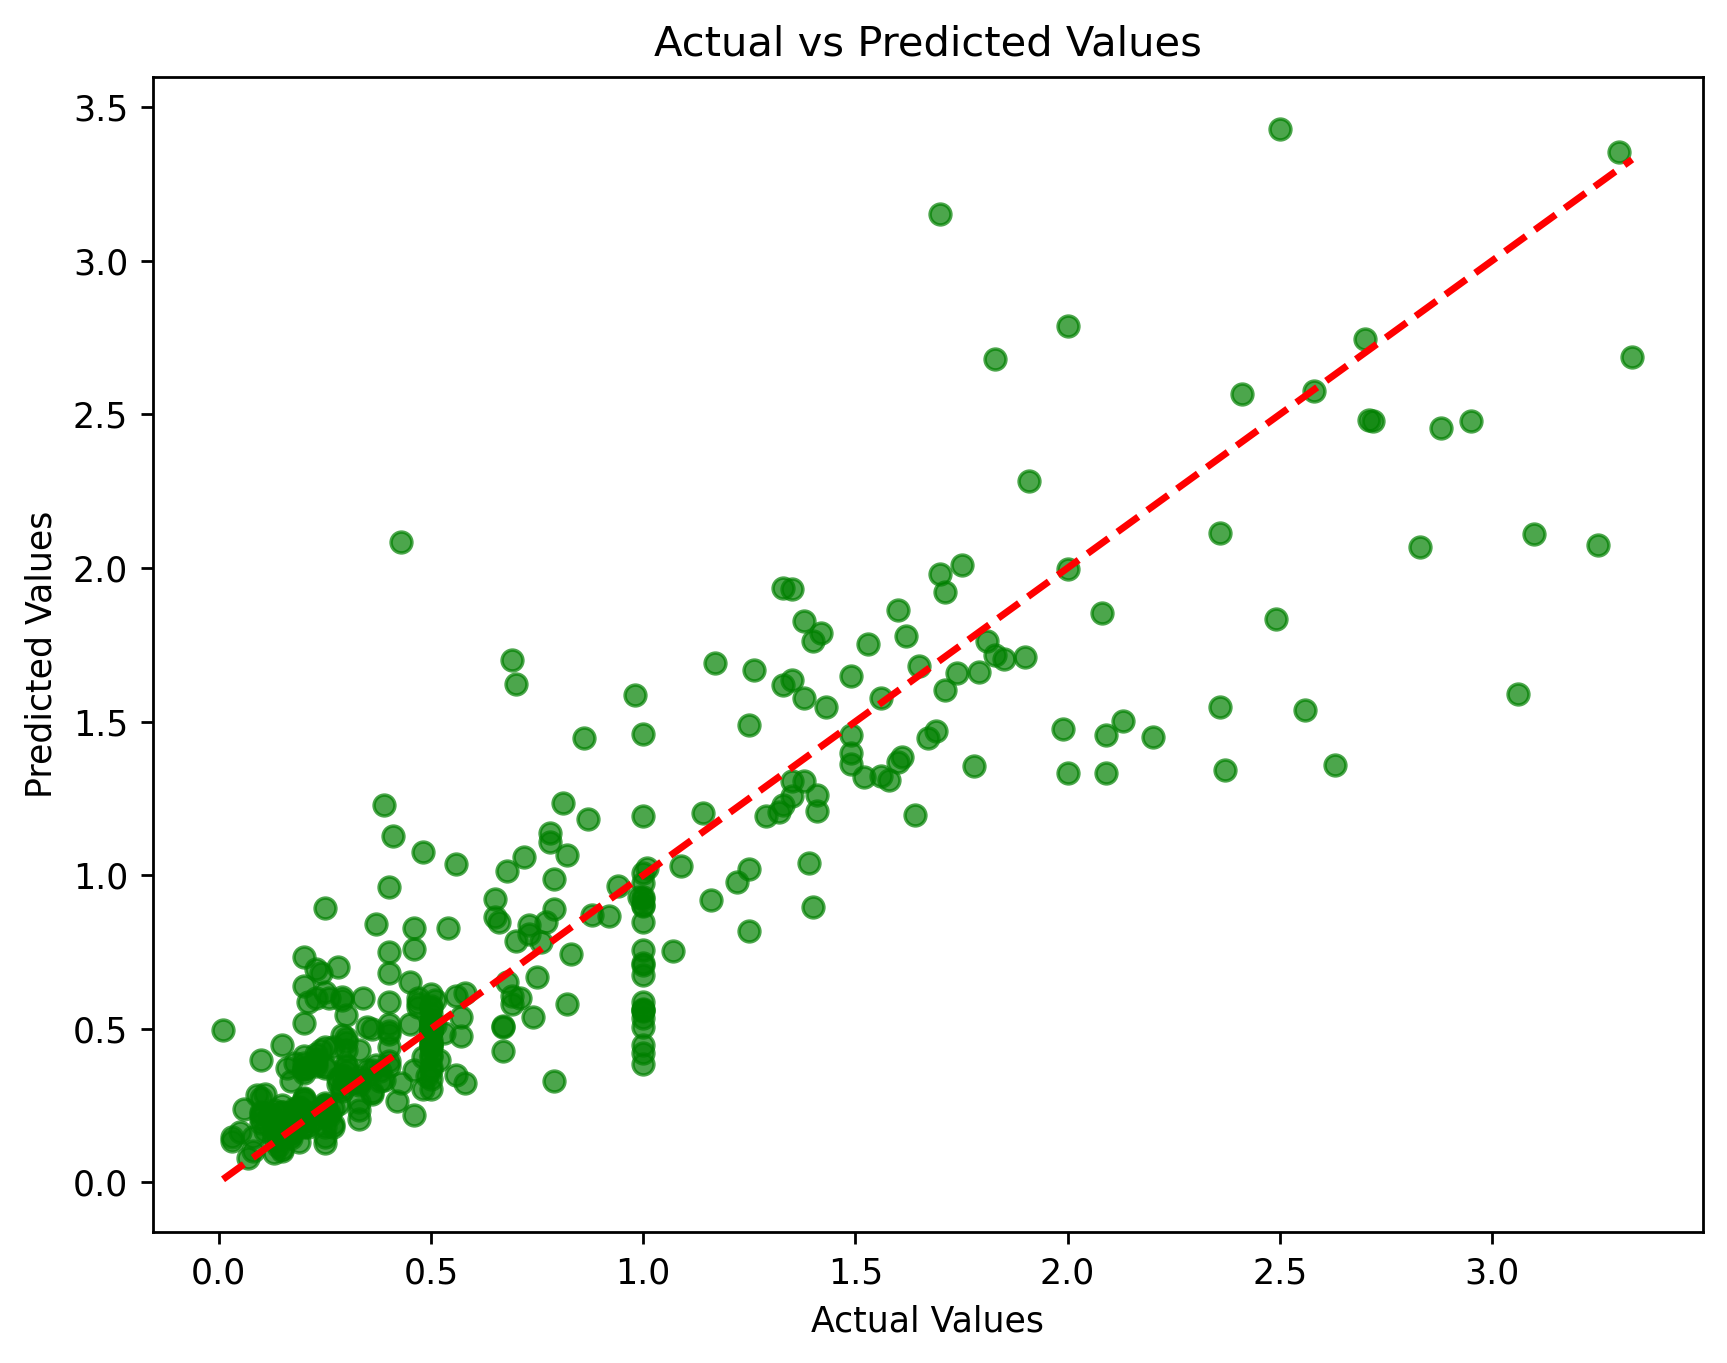

In [26]:
# Visualization of predictions vs actual values for the last model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_model, alpha=0.7, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [27]:
pred_values=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred_best_model})
pred_values

,Actual Value,Predicted Value
1794,0.25,0.6181
1329,0.20,0.2005
876,1.62,1.7791
1750,0.01,0.4954
1512,0.14,0.1185
...,...,...
1608,0.20,0.1999
294,0.33,0.3421
836,0.77,0.8477
1036,0.58,0.3232
